### ***727723EUAI109 : Sanjay M***

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

np.random.seed(42)
tf.random.set_seed(42)

X = np.random.randn(500, 20, 1)
y = (X[:, 0, 0] > 0).astype(int)  # label depends on first step only

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (400, 20, 1), Test: (100, 20, 1)


In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense

def build_rnn():
    model = Sequential([
        SimpleRNN(32, input_shape=(20, 1)),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_lstm():
    model = Sequential([
        LSTM(32, input_shape=(20, 1)),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])
    return model

rnn_model  = build_rnn()
lstm_model = build_lstm()

print("Training RNN...")
rnn_history  = rnn_model.fit(X_train, y_train, epochs=50, batch_size=32,
                              validation_data=(X_test, y_test), verbose=0)

print("Training LSTM...")
lstm_history = lstm_model.fit(X_train, y_train, epochs=50, batch_size=32,
                               validation_data=(X_test, y_test), verbose=0)

print(f"RNN  final val accuracy : {rnn_history.history['val_accuracy'][-1]:.4f}")
print(f"LSTM final val accuracy : {lstm_history.history['val_accuracy'][-1]:.4f}")

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training RNN...
Training LSTM...
RNN  final val accuracy : 0.9100
LSTM final val accuracy : 0.5000


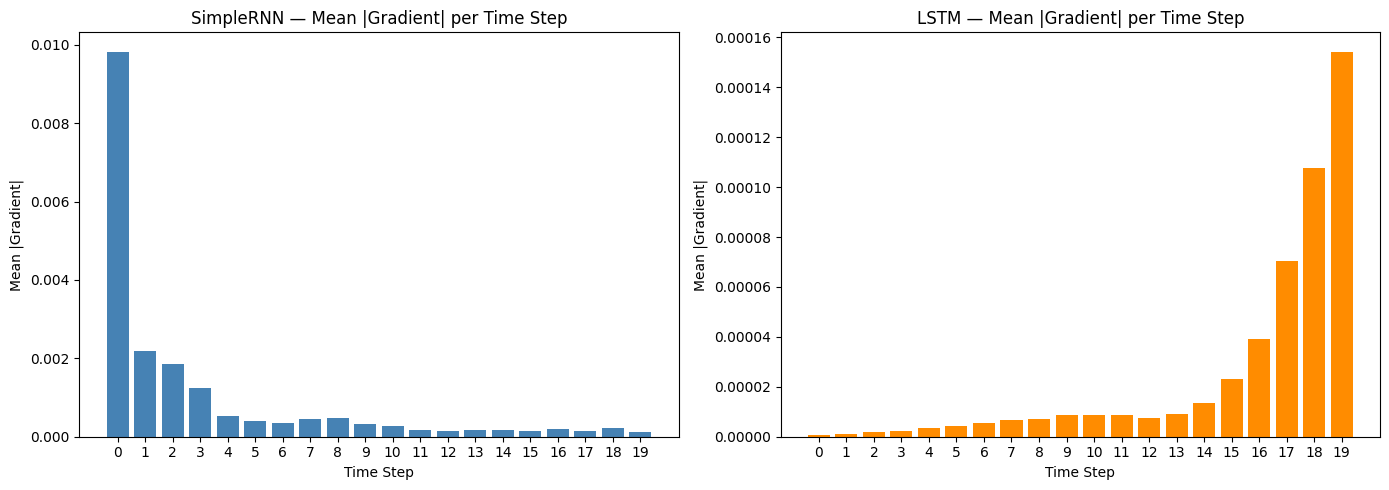

RNN  |grad| at step 0 : 0.009826  |  step 19 : 0.000130
LSTM |grad| at step 0 : 0.000001  |  step 19 : 0.000154


In [3]:
def compute_input_gradients(model, X_batch, y_batch):
    """Return mean absolute gradient per time step (shape: [20])."""
    X_tensor = tf.constant(X_batch, dtype=tf.float32)
    y_tensor = tf.constant(y_batch, dtype=tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(X_tensor)
        preds = model(X_tensor, training=False)
        loss  = tf.keras.losses.binary_crossentropy(y_tensor, tf.squeeze(preds))
        loss  = tf.reduce_mean(loss)

    grads = tape.gradient(loss, X_tensor)   # shape: (batch, 20, 1)
    return tf.reduce_mean(tf.abs(grads), axis=[0, 2]).numpy()  # shape: (20,)

# Use the full test set as the inspection batch
X_batch = X_test
y_batch = y_test

rnn_grads  = compute_input_gradients(rnn_model,  X_batch, y_batch)
lstm_grads = compute_input_gradients(lstm_model, X_batch, y_batch)

steps = np.arange(20)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

axes[0].bar(steps, rnn_grads, color='steelblue')
axes[0].set_title('SimpleRNN — Mean |Gradient| per Time Step')
axes[0].set_xlabel('Time Step')
axes[0].set_ylabel('Mean |Gradient|')
axes[0].set_xticks(steps)

axes[1].bar(steps, lstm_grads, color='darkorange')
axes[1].set_title('LSTM — Mean |Gradient| per Time Step')
axes[1].set_xlabel('Time Step')
axes[1].set_ylabel('Mean |Gradient|')
axes[1].set_xticks(steps)

plt.tight_layout()
plt.savefig('gradient_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"RNN  |grad| at step 0 : {rnn_grads[0]:.6f}  |  step 19 : {rnn_grads[19]:.6f}")
print(f"LSTM |grad| at step 0 : {lstm_grads[0]:.6f}  |  step 19 : {lstm_grads[19]:.6f}")